# Customer Segmentation & Churn Prediction Analysis

In this project, I analyze transaction data to identify high-value customer segments and predict churn risk to inform marketing retention strategies.

The dataset used here comes from [https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci?resource=download](this Kaggle page:)

In [64]:
import pandas as pd
import numpy as np
import datetime as dt
import seaborn as sns
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer
import math
import missingno as msno
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [65]:
data_path = r'../data/online_retail_II.csv'
df = pd.read_csv(data_path)
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [66]:
pd.set_option('display.max_rows', None)      # show all rows
pd.set_option('display.width', None)         # auto-detect display width
pd.set_option('display.max_colwidth', None)  # show full content in each column

def data_overview(df, head=10):
    print(' DIMENSIONALITY '.center(125, '-'))
    print('Rows:{}'.format(df.shape[0]))
    print('Columns:{}'.format(df.shape[1]))
    print(' DISTRIBUTION OF DATA TYPES '.center(125, '-'))
    print(df.dtypes.value_counts())
    print(' MISSING VALUES '.center(125, '-'))
    print(df.isnull().sum()[df.isnull().sum()>0].sort_values(ascending = False))
    print(' DUPLICATED VALUES '.center(125,'-'))
    print(df.duplicated().sum())
    print(' STATISTICS OF DATA '.center(125,'-'))
    print(df.describe(include="all"))
    print(' DATA INFO '.center(125,'-'))
    print(df.info())
    

# make a copy of the dataframe for manipulation
data = df
data_overview(data)

------------------------------------------------------- DIMENSIONALITY ------------------------------------------------------
Rows:1067371
Columns:8
------------------------------------------------- DISTRIBUTION OF DATA TYPES ------------------------------------------------
object     5
float64    2
int64      1
Name: count, dtype: int64
------------------------------------------------------- MISSING VALUES ------------------------------------------------------
Customer ID    243007
Description      4382
dtype: int64
----------------------------------------------------- DUPLICATED VALUES -----------------------------------------------------
34335
----------------------------------------------------- STATISTICS OF DATA ----------------------------------------------------
        Invoice StockCode                         Description      Quantity  \
count   1067371   1067371                             1062989  1.067371e+06   
unique    53628      5305                                5698

---
# DATA WRANGLING
---

### (1) Removing Missing Data:

<Axes: >

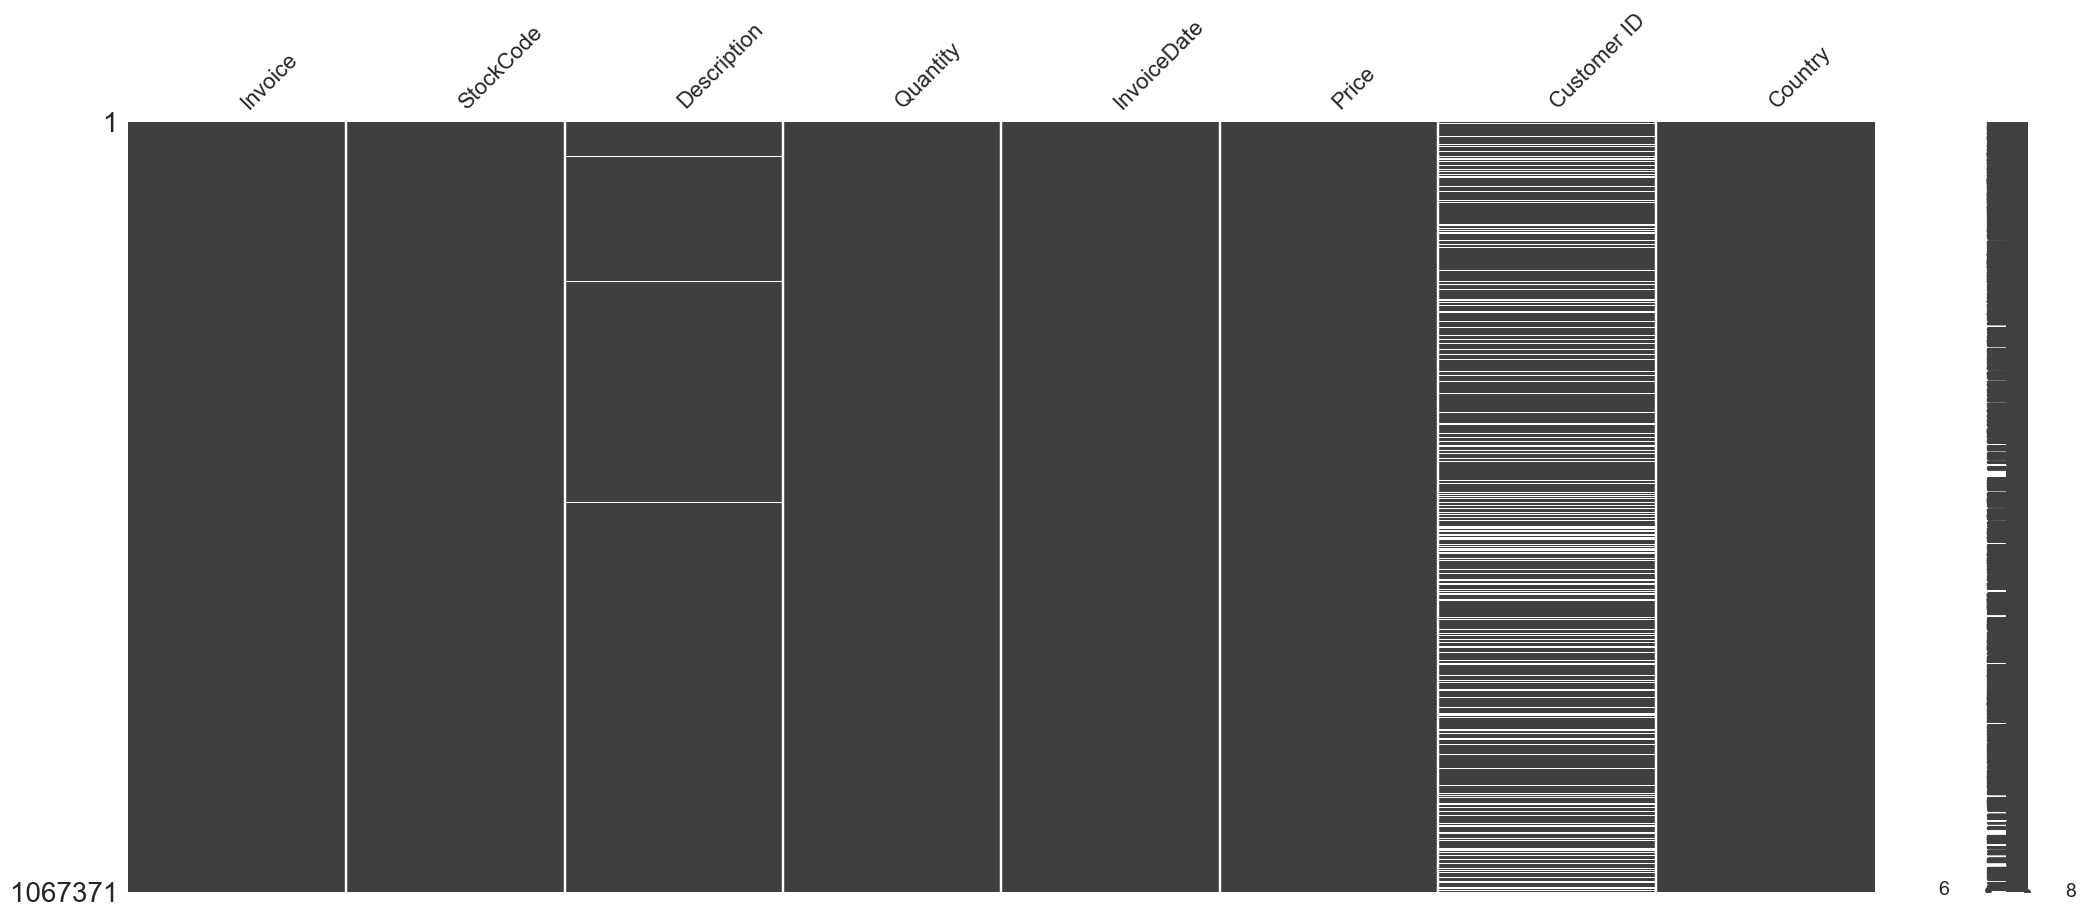

In [67]:
msno.matrix(data)

### There is no point in holding onto data without a customer ID when attempting to prevent or minimize churn, so we should eliminate any rows with missing ID.

In [68]:
#  Removing NaN's in Customer ID
print("Shape of data before removing NaN's CustomerID", data.shape)
data.dropna(subset=["Customer ID"], axis=0, inplace=True)
print("Shape of data after removing NaN's CustomerID", data.shape)

Shape of data before removing NaN's CustomerID (1067371, 8)
Shape of data after removing NaN's CustomerID (824364, 8)


In [69]:
print("Missing values in each column after cleaning customerID :\n", data.isnull().sum())

Missing values in each column after cleaning customerID :
 Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


<Axes: >

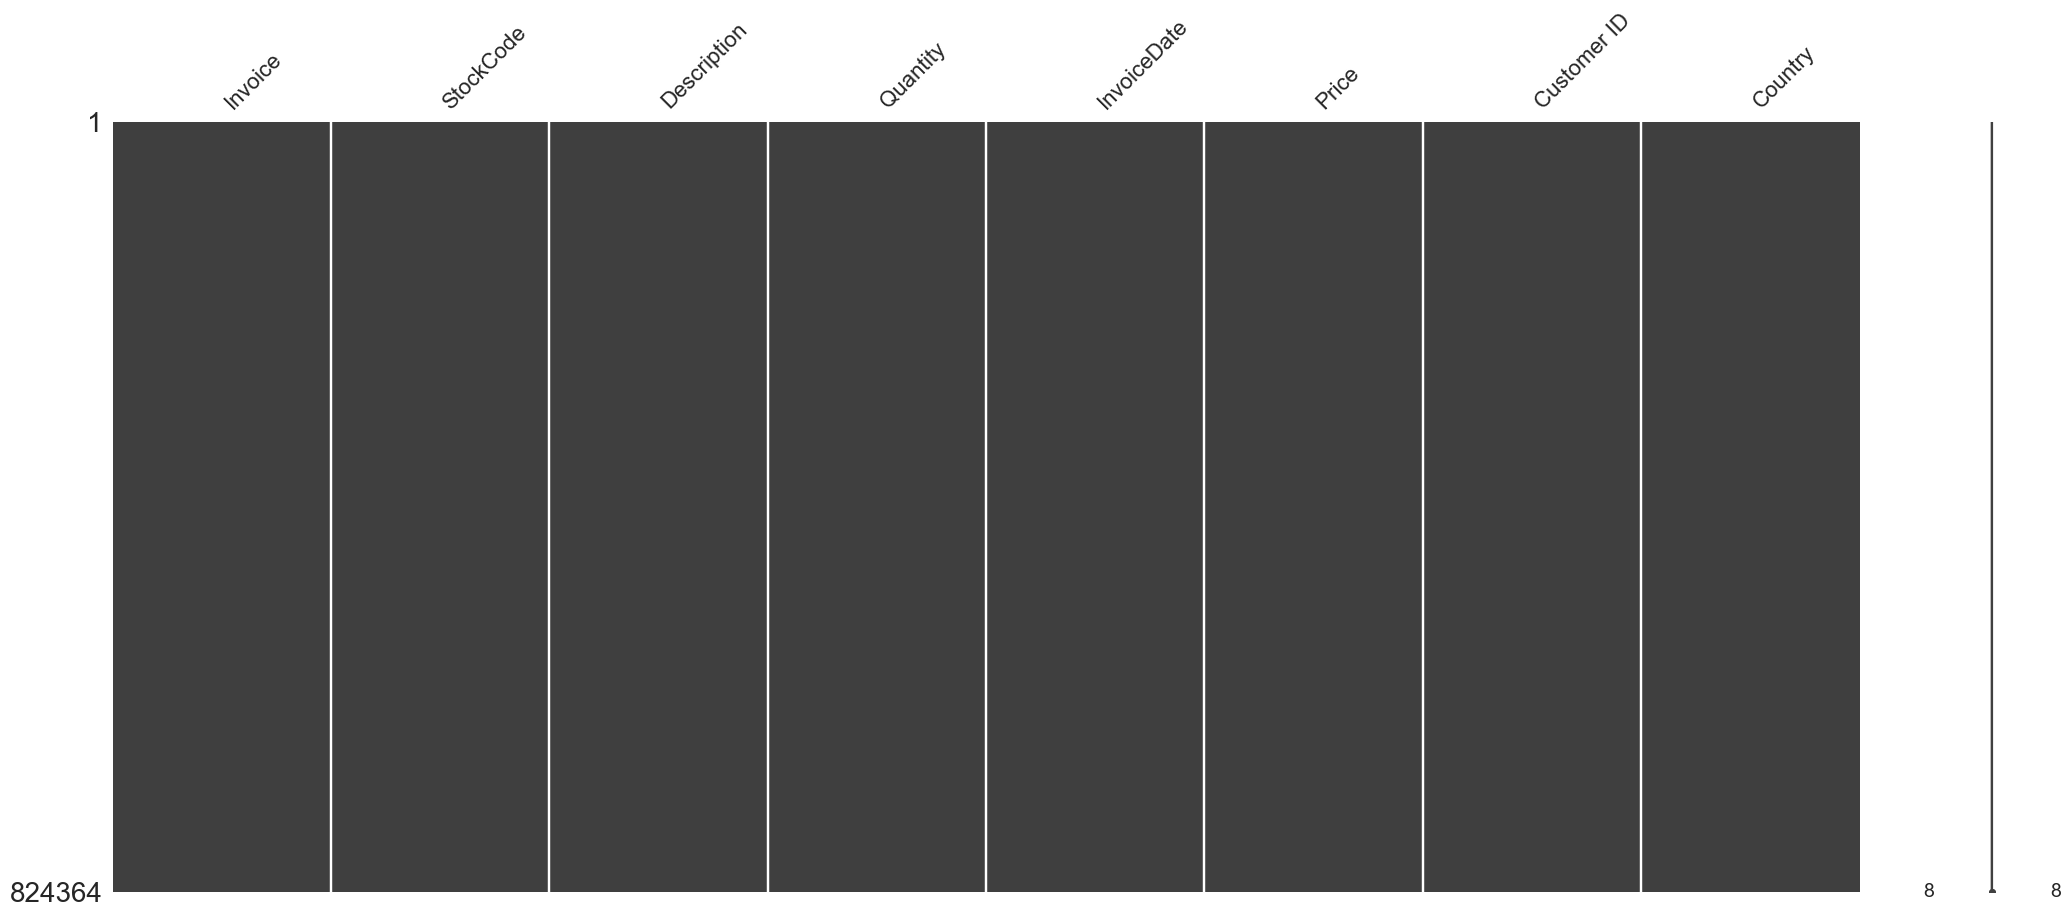

In [70]:
msno.matrix(data)

### (2) Removing Cancelled Products from Invoice:

In [71]:
#using one's compliment operator (~) we can unselect all the Invoice column which doesnt contain "C".
data = data[~data.Invoice.str.contains('C', na=False)]
print("Dataset does not contain info on cancelled products")

Dataset does not contain info on cancelled products


### (3) Removing Duplicates:

In [72]:
# Removing duplicates entries (where values in all columns are identical)
print("Number of duplicates before cleaning:", data.duplicated().sum())
data = data.drop_duplicates(keep="first")
print("Number of duplicates after cleaning:", data.duplicated().sum())

Number of duplicates before cleaning: 26125
Number of duplicates after cleaning: 0


### (4) Checking for Negative Values:

In [73]:
print("Negative value in Quantity is:", (data.Quantity<0).sum())
print("Negative value in Price is:", (data.Price<0).sum())

Negative value in Quantity is: 0
Negative value in Price is: 0


### (5) Cleaning Outliers

In [74]:
#defining funcation to remove outliers w.r.t its thresholds
def outlier_thresholds(dataframe, variable):
    quartile1 = dataframe[variable].quantile(0.01)
    quartile3 = dataframe[variable].quantile(0.99)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return up_limit, low_limit

def replace_with_threshold(dataframe, variable):
    up_limit, low_limit = outlier_thresholds(dataframe, variable)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

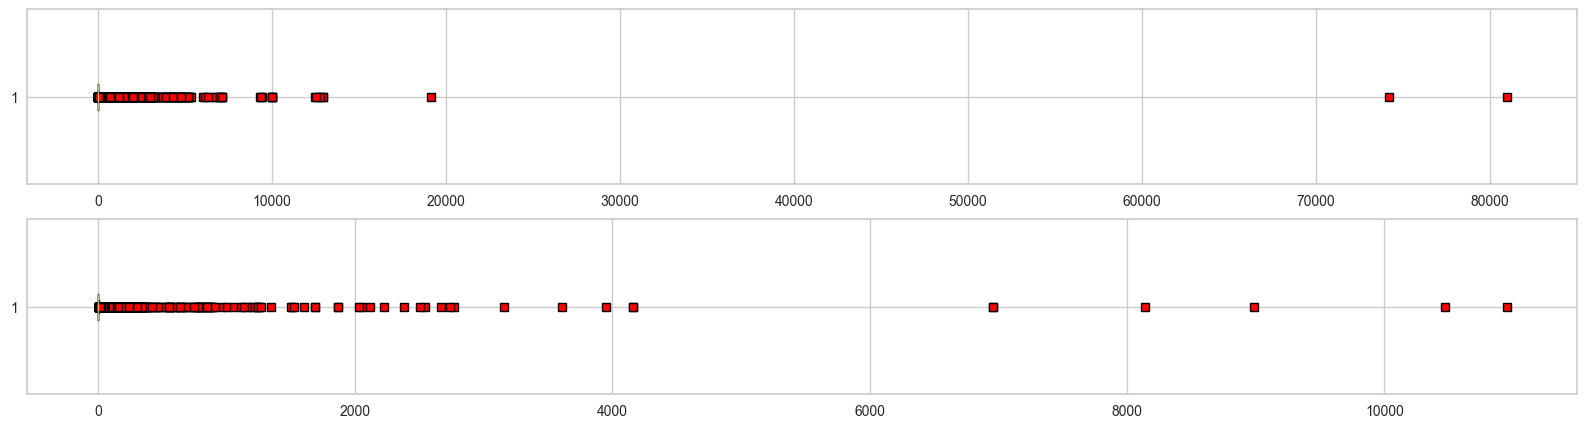

In [75]:
# Observing them BEFORE removing outliers.
f, ax = plt.subplots(2, 1, figsize=(20,5))
col_list = ["Quantity", "Price"]
for i in range(0,2):
    ax[i].boxplot([data[col_list[i]]],
              flierprops=dict(marker="s", markerfacecolor="red"),
              vert=False)
plt.show()

In [76]:
# Applying the functions for removing the outliers.
replace_with_threshold(data, "Quantity")
replace_with_threshold(data, "Price")

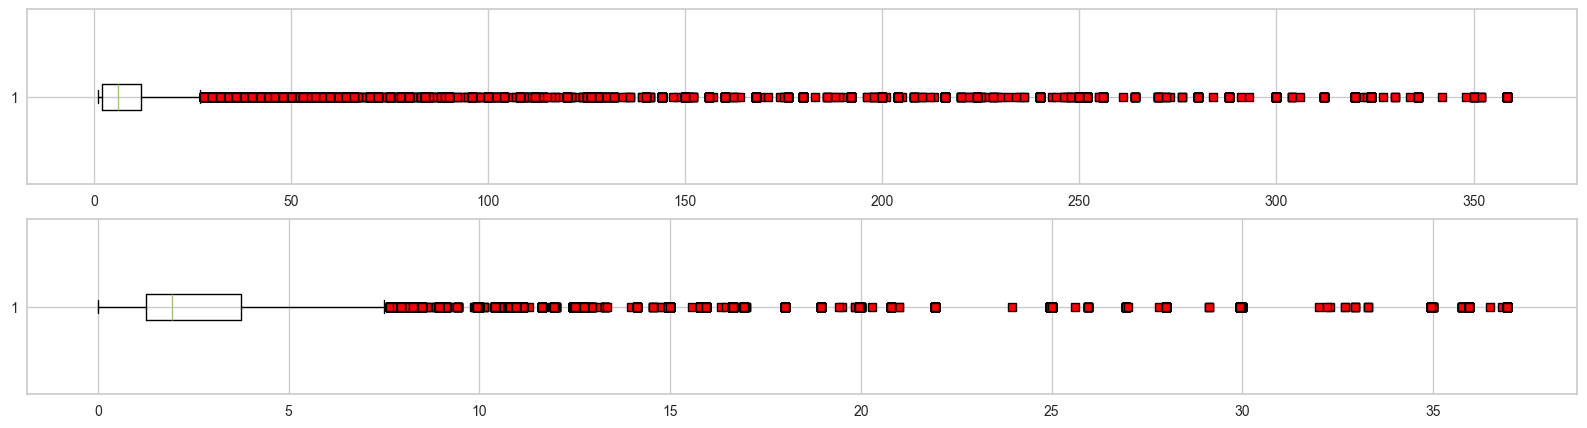

In [77]:
# Observing them AFTER removing outliers.
f, ax = plt.subplots(2, 1, figsize=(20,5))
for i in range(0,2):
    ax[i].boxplot([data[col_list[i]]],
              flierprops=dict(marker="s", markerfacecolor="red"),
              vert=False)
plt.show()

## Data is Clean 

---
# Exploratory Data Analysis & Feature Engineering
---

In [78]:
#First, we define a new feature called "Revenue" which is the quantity of an item multiplied by its unit price:
data["Revenue"] = data["Quantity"] * data["Price"]

In [79]:
#Creating Features for RFM Model
#Changing data type to datetime
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

In [80]:
print("Latest date :", data["InvoiceDate"].max())
print("Earliest date :", data["InvoiceDate"].min())

Latest date : 2011-12-09 12:50:00
Earliest date : 2009-12-01 07:45:00


## RFM* Featuring
#### *Recency, Frequency and Monetary

In [81]:
#Set Latest date 2011-12-10 as last invoice date was 2011-12-09.
Latest_Date = dt.datetime(2011,12,10)

#Creating RFM features with subset of customerID, by collapsing the dataset so that each row = one customer.

RFM = data.groupby('Customer ID').agg({'InvoiceDate': lambda x: (Latest_Date - x.max()).days, 
                                       'Invoice': lambda x: x.nunique(), 
                                       'Revenue': lambda x: x.sum()})
                                
RFM['InvoiceDate'] = RFM['InvoiceDate'].astype(int)

#Renaming column names to Recency, Frequency and Monetary
RFM.rename(columns={'InvoiceDate': 'Recency', 
                         'Invoice': 'Frequency', 
                         'Revenue': 'Monetary'}, inplace=True)

In [82]:
RFM.head().style.format({
    "Recency": "{:.0f}",
    "Frequency": "{:.0f}",
    "Monetary": "{:.2f}"
})

,Recency,Frequency,Monetary
Customer ID,,,
12346.000000,325,12,745.70
12347.000000,2,8,4921.53
12348.000000,75,5,1991.86
12349.000000,18,4,3786.50
12350.000000,310,1,331.34


Now, for each customer we have how recent, how often they've purchased goods, as well as how much in total they've spent.

## Add a New Feature: Customer Lifespan

In [83]:
# First, we filter out any one-timers, and consider only returning customers:
RFM = RFM[(RFM['Frequency'] > 1)]
RFM.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,325,12,745.70
12347.0,2,8,4921.53
12348.0,75,5,1991.86
12349.0,18,4,3786.50
12352.0,36,10,2098.94


In [84]:
shopping_cycle = data.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (x.max() - x.min()).days
}).rename(columns={'InvoiceDate': 'Shopping Cycle'})

RFM = RFM.join(shopping_cycle)
RFM.head()

,Recency,Frequency,Monetary,Shopping Cycle
Customer ID,,,,
12346.0,325,12,745.70,400
12347.0,2,8,4921.53,402
12348.0,75,5,1991.86,362
12349.0,18,4,3786.50,570
12352.0,36,10,2098.94,356


In [85]:
RFM['Interpurchase Time'] = RFM['Shopping Cycle'] // RFM['Frequency']
RFMT = RFM[['Recency', 'Frequency', 'Monetary', 'Interpurchase Time']]
RFMT.head()

,Recency,Frequency,Monetary,Interpurchase Time
Customer ID,,,,
12346.0,325,12,745.70,33
12347.0,2,8,4921.53,50
12348.0,75,5,1991.86,72
12349.0,18,4,3786.50,142
12352.0,36,10,2098.94,35


In [86]:
#scaling data 
scaler = StandardScaler()
rfmt_scaled = scaler.fit_transform(RFMT)
rfmt_scaled = pd.DataFrame(rfmt_scaled)
rfmt_scaled.head()

,0,1,2,3
0,1.084371,0.249370,-0.191464,-0.674702
1,-0.831478,-0.020777,0.077446,-0.355286
2,-0.398484,-0.223387,-0.111216,0.058076
3,-0.736575,-0.290924,0.004353,1.373320
4,-0.629810,0.114297,-0.104320,-0.637124


---
# Modeling with K-Means Algorithm
---

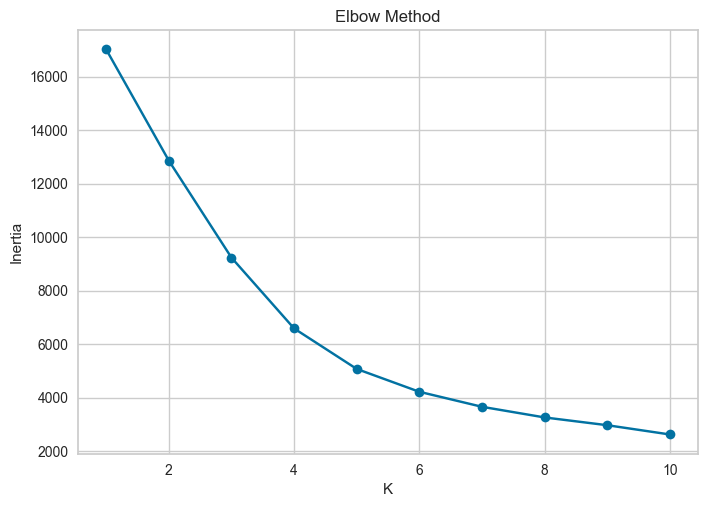

In [87]:
inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    model.fit(rfmt_scaled)
    inertia.append(model.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [88]:
from sklearn.metrics import silhouette_score

for k in range(2,11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(rfmt_scaled)

    score = silhouette_score(rfmt_scaled, labels)

    print(k, score)

2 0.8718196699608133
3 0.4191955101592523
4 0.44282368792966215
5 0.4518440285937613
6 0.4400274675402422
7 0.38657456902590975
8 0.3865379638829121
9 0.36442812902121274
10 0.36648275578924505


Two clusters results in the highest score (0.87), but the next-highest and decent score of 0.45 is for N=5 clusters, so let's proceed and see if anything meaningful can result from considering N=5. Effectively we're asking, "Can a 5-segment solution reveal actionable customer personas that are hidden inside the broader Active vs Inactive split?"

In [89]:
#Fitting KMeans Model
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

RFMT['Cluster5'] = kmeans.fit_predict(rfmt_scaled)

In [90]:
# RFMT.groupby('Cluster5').mean()

#### skewed spending could lead to median being a better measure of "average" than mean:

cluster_profile = RFMT.groupby('Cluster5').agg({
    'Recency':['mean','median'],
    'Frequency':['mean','median'],
    'Monetary':['mean','median'],
    'Interpurchase Time':['mean','median']
}).round(2)

print(cluster_profile)

         Recency        Frequency          Monetary             \
            mean median      mean median       mean     median   
Cluster5                                                         
0          96.65   63.0      3.46    3.0    1221.46     900.65   
1         420.15  407.0      3.79    3.0    1250.52     780.58   
2          50.18   28.0     10.36    8.0    4040.77    2345.28   
3          26.15    3.0    106.74   88.5   73425.95   56451.92   
4           2.75    1.0    212.75  154.0  405626.43  404881.66   

         Interpurchase Time         
                       mean median  
Cluster5                            
0                    147.01  134.0  
1                     47.44   43.0  
2                     46.18   46.0  
3                      7.82    7.5  
4                      3.50    4.0  


In [91]:
cluster_sizes = RFMT['Cluster5'].value_counts().sort_index()

print(cluster_sizes)

print(round((cluster_sizes / len(RFMT))*100, 0), " %")

Cluster5
0     962
1     940
2    2315
3      34
4       4
Name: count, dtype: int64
Cluster5
0    23.0
1    22.0
2    54.0
3     1.0
4     0.0
Name: count, dtype: float64  %


**CONCLUSIONS:** There are 3 groups of comparable amount (clusters 0 and 1 are roughly same size, cluster 3 contains about twice as many as either 0 or 1. But then clusters 3 and 4 are such a small fraction of the total (<2% combined), so while likely representing distinct purchasing behavior from the customers in the first three clusters/groups, we will be safe in ignoring for 

-------------------
# Visualizations
-------------------

We'll start off by looking at all possible combinations of the 4 features in 4x4=16 
## 1. pairplots:

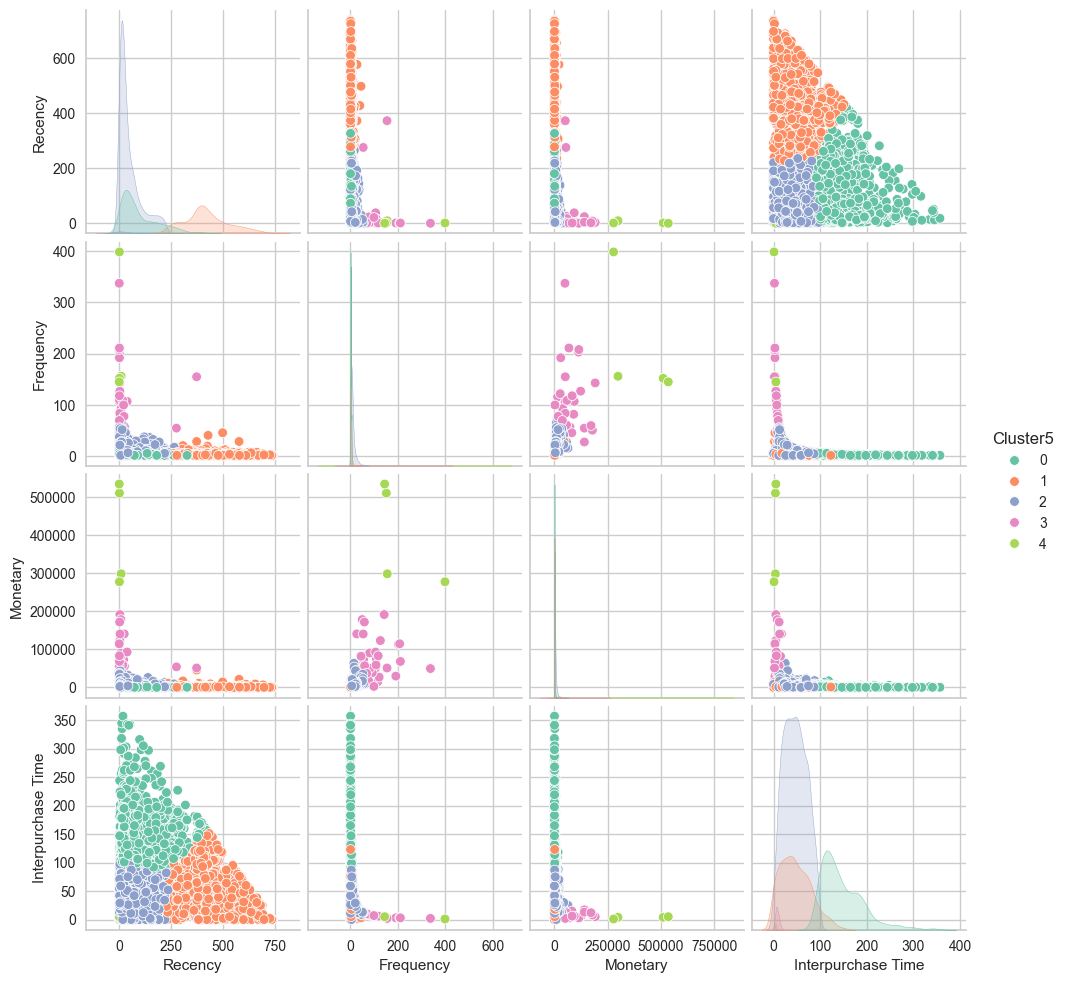

In [92]:
sns.pairplot(
    RFMT,
    vars=['Recency','Frequency','Monetary','Interpurchase Time'],
    hue='Cluster5',
    palette='Set2'
)

plt.show()

## 2. PCA Visualization

**Principle Component Analysis (PCA)** is a statistical technique used to reduce the dimensionality of a dataset while preserving as much variance as possible. It transforms the original variables into a new set of uncorrelated variables called principal components, which capture the most significant information from the data.

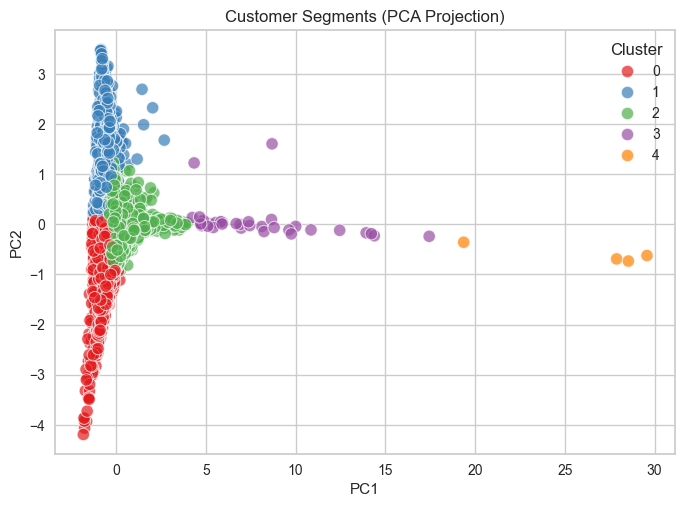

In [93]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)

coords = pca.fit_transform(rfmt_scaled)

plot_df = pd.DataFrame({
    'PC1': coords[:,0],
    'PC2': coords[:,1],
    'Cluster': RFMT['Cluster5']
})

sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=80,
    alpha=0.7
)

plt.title("Customer Segments (PCA Projection)")
plt.show()

## 3. Profile each cluster:

In [94]:
cluster_profile = RFMT.groupby('Cluster5').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean',
    'Interpurchase Time':'mean'
}).round(2)

# cluster_profile = RFMT.groupby('Cluster5').agg({
#     'Recency':['mean','median'],
#     'Frequency':['mean','median'],
#     'Monetary':['mean','median'],
#     'Interpurchase Time':['mean','median']
# }).round(2)

print(cluster_profile)

          Recency  Frequency   Monetary  Interpurchase Time
Cluster5                                                   
0           96.65       3.46    1221.46              147.01
1          420.15       3.79    1250.52               47.44
2           50.18      10.36    4040.77               46.18
3           26.15     106.74   73425.95                7.82
4            2.75     212.75  405626.43                3.50


# 4. Radar chart for cluster comparison

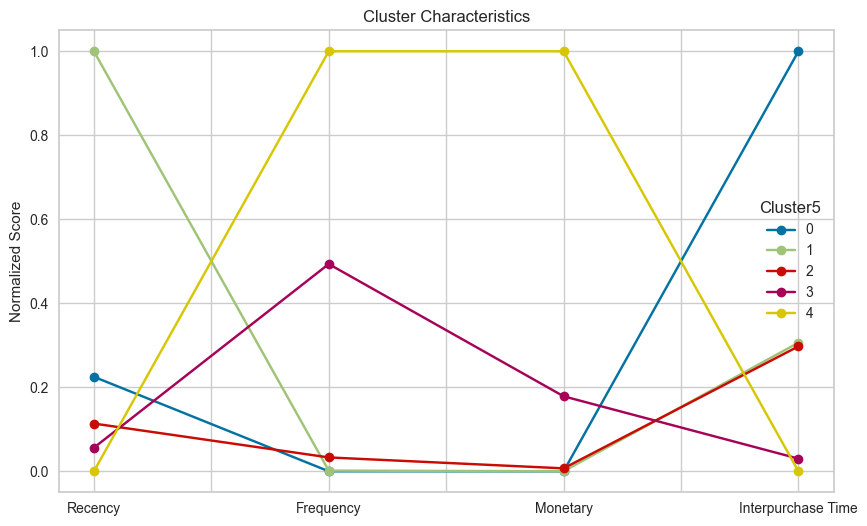

In [95]:
cluster_profile_scaled = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())

cluster_profile_scaled.T.plot(
    kind='line',
    figsize=(10,6),
    marker='o'
)

plt.title("Cluster Characteristics")
plt.ylabel("Normalized Score")
plt.show()


# Marketing Interpretation
-----------------


**<mark style="background-color: yellow">Cluster 4 (yellow): VIP Customers</mark>**

* Most recent purchases (lowest recency).
* Purchases at highest frequency and spending.
* Very low interpurchase time.

**Business impact:** Retaining this group, even if less than 1% of customers, produces the highest revenue preservation.

**Marketing actions:**

* Loyalty rewards
* Early product access
* Premium offers/memberships



------------------------

**<mark style="background-color: lightgreen">Cluster 1 (green): Dormant / Lost Customers</mark>**

Characteristics:
* Highest Recency (Have not purchased recently)
* Lowest Frequency
* Lowest Monetary 
* Long Interpurchase Time

**Business impact:** These customers appear to not purchased recently, purchase infrequently and spend little. Thus, these customers have **high churn probability**.

**Marketing action:**

* Win-back/re-engagement campaigns (emails)
* Discount offers
* Possibly low marketing priority

-----------------

**<mark style="background-color: purple; color: white">Cluster 3 (purple): Growth Potential</mark>**

Characteristics:
* Moderately recent
* Moderate Frequency
* Moderate Monetary
* Fairly short Interpurchase Time

**Business impact:** This cluster looks balanced; they aren't spending like Champions, but **they appear engaged** (more than average customers).

**Marketing action:**

* Upselling
* Cross-selling
* Membership incentives

----------------------

**<mark style="background-color: blue; color: white">Cluster 0 (blue)</mark> and <mark style="background-color: red; color: white">2 (red)</mark>:** Hard to interpret from this plot alone

This is where the radar chart reaches its limits.

**<mark style="background-color: blue; color: white">Cluster 0 (blue)</mark>**

* Somewhat recent
* Low Frequency
* Low Monetary
* Longest Interpurchase Time

This could be:

* Occasional shoppers
* Seasonal shoppers
* One-time buyers

**<mark style="background-color: red; color: white">Cluster 2 (red)</mark>:**

* Slightly better Frequency and Monetary than Cluster 0
* Similar Interpurchase Time

These could be either new customers, or low-value active customers

But we really need the actual means and cluster sizes.

-----------------

## Conclusions based on Radar Chart:
A five-cluster solution revealed a high-value Champion segment characterized by frequent purchases, high spending, and short interpurchase intervals, alongside a Dormant segment with infrequent and outdated purchasing behavior. Intermediate segments displayed varying levels of engagement and spending, suggesting opportunities for targeted retention and upselling campaigns.

## 5. How many customers are in each segment?

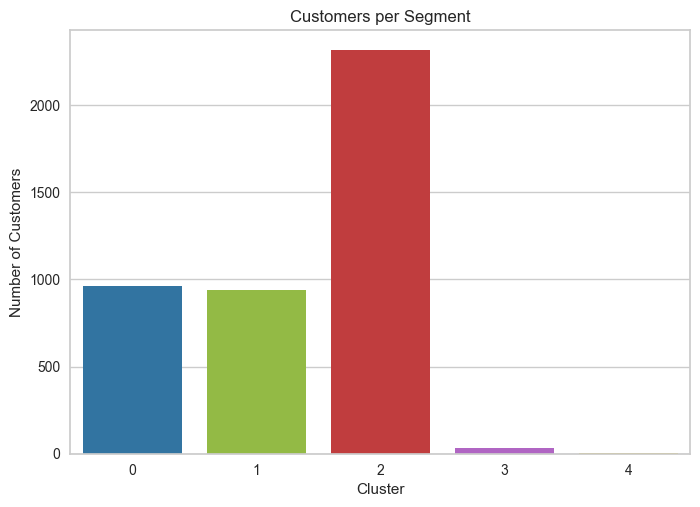

In [96]:
cluster_colors = {
    0: 'tab:blue',
    1: 'yellowgreen',
    2: 'tab:red',
    3: 'mediumorchid',
    4: 'gold'
}

sns.countplot(
    data=RFMT,
    x='Cluster5',
    hue='Cluster5',
    palette=cluster_colors,
    legend=False
)

plt.title("Customers per Segment")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

## 6. How much money comes from each segment?

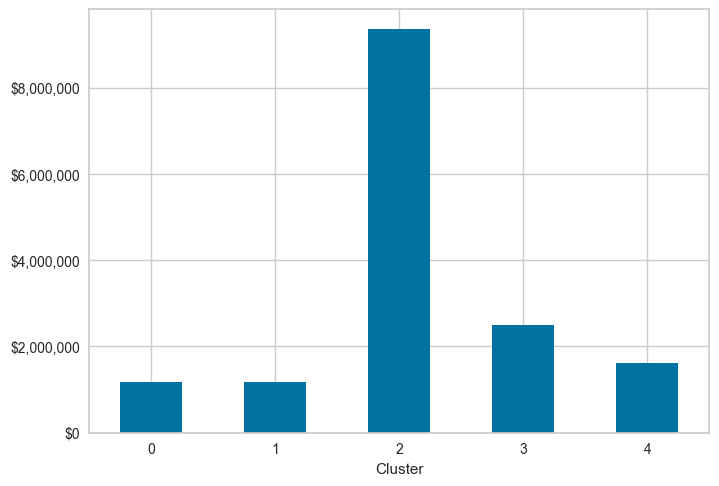

In [97]:
# revenue_by_cluster = RFMT.groupby('Cluster5')['Monetary'].sum()

# revenue_by_cluster.plot(kind='bar')

import matplotlib.ticker as ticker

ax = revenue_by_cluster.plot(kind='bar')
palette=cluster_colors

ax.yaxis.set_major_formatter(
    ticker.StrMethodFormatter('${x:,.0f}')
)

plt.xticks(rotation=0)
plt.xlabel('Cluster')
plt.show()

In [42]:
100 * revenue_by_cluster / revenue_by_cluster.sum()

Cluster5
0     7.425762
1     7.428537
2    59.115546
3    15.776646
4    10.253508
Name: Monetary, dtype: float64

## Insight: 
Customer behavior is highly heterogeneous. More than half of customers belong to a large middle segment, while a very small number of customers exhibit dramatically different purchasing behavior. This suggests that broad-based retention and upselling strategies targeting the majority segment may generate greater overall business impact than focusing exclusively on high-value outliers.

----------------

## 7. What is the Revenue per Customer?

Now, let's combine the last two plots to find the revenue per customer for each group, in order to see which groups hold the most value for the company.

In [98]:
import pandas as pd

data = {
    "Cluster": [0, 1, 2, 3, 4],
    "Total Revenue": [1.2e6, 1.2e6, 9.3e6, 2.5e6, 1.6e6],
    "Customers": [960, 940, 2320, 35, 2],
    "Revenue per Customer": [1250, 1275, 4000, 71428, 800000],
    "Interpretation": [
        "Low-value, high-volume segment",
        "Similar to Cluster 0 (commodity users)",
        "Mid-tier core customer base",
        "High-value enterprise / premium accounts",
        "Ultra-high-value 'whale' customers"
    ]
}

df = pd.DataFrame(data)

# Formatting helper for display
def fmt_money(x):
    if x >= 1e6:
        return f"${x/1e6:.1f}M"
    elif x >= 1e3:
        return f"${x/1e3:.1f}K"
    return str(x)

styled = (
    df.style
    .format({
        "Total Revenue": fmt_money,
        "Revenue per Customer": fmt_money
    })
    .background_gradient(subset=["Total Revenue"], cmap="Blues")
    .background_gradient(subset=["Revenue per Customer"], cmap="Reds")
    .bar(subset=["Customers"], color="#5fba7d")
    .set_properties(subset=["Interpretation"], **{"text-align": "left"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "td", "props": [("padding", "6px")]}
    ])
)

styled.hide(axis="index")
# styled.highlight_max(subset=["Revenue per Customer"], color="gold")

Cluster,Total Revenue,Customers,Revenue per Customer,Interpretation
0,$1.2M,960,$1.2K,"Low-value, high-volume segment"
1,$1.2M,940,$1.3K,Similar to Cluster 0 (commodity users)
2,$9.3M,2320,$4.0K,Mid-tier core customer base
3,$2.5M,35,$71.4K,High-value enterprise / premium accounts
4,$1.6M,2,$800.0K,Ultra-high-value 'whale' customers


# 📊 Dashboard-Style Summary

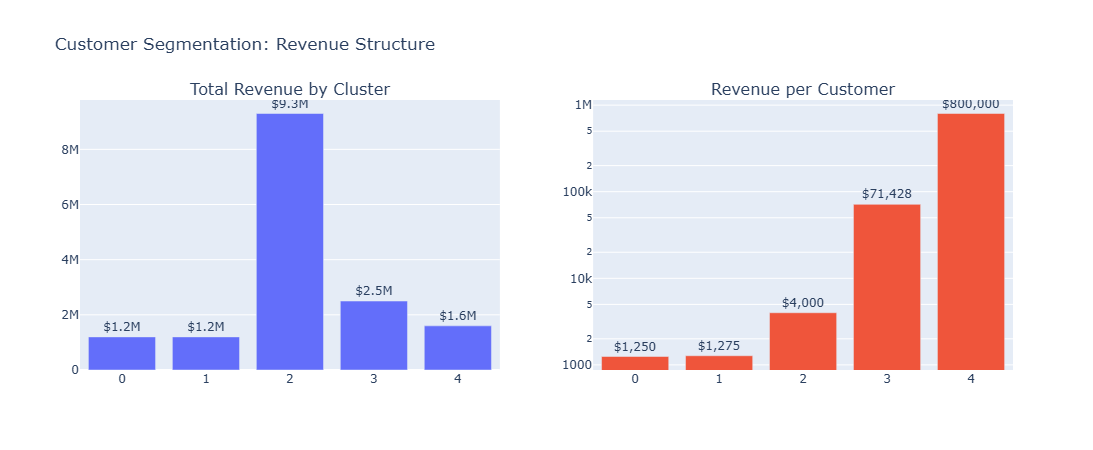

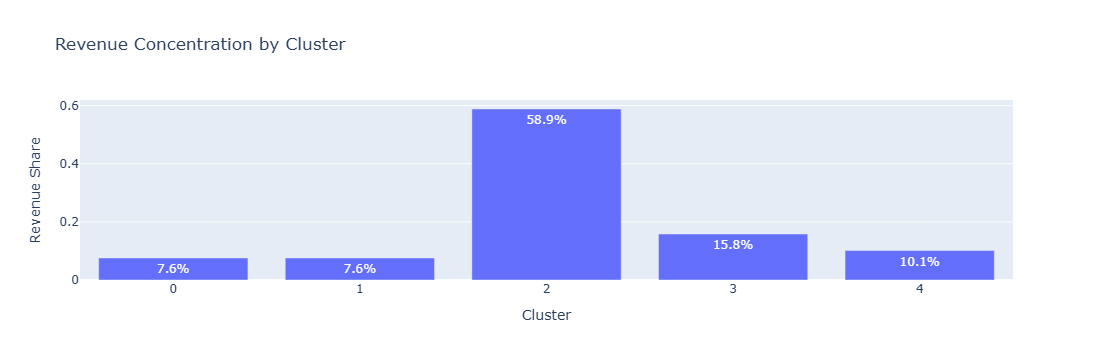

In [99]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

df["Total Revenue Raw"] = df["Total Revenue"]
df["RPC Raw"] = df["Revenue per Customer"]

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Total Revenue by Cluster", "Revenue per Customer"),
)

# Total Revenue
fig.add_trace(
    go.Bar(
        x=df["Cluster"],
        y=df["Total Revenue Raw"],
        text=[f"${v/1e6:.1f}M" for v in df["Total Revenue Raw"]],
        textposition="outside"
    ),
    row=1, col=1
)

# Revenue per customer (log scale helps a LOT here)
fig.add_trace(
    go.Bar(
        x=df["Cluster"],
        y=df["RPC Raw"],
        text=[f"${v:,.0f}" for v in df["RPC Raw"]],
        textposition="outside"
    ),
    row=1, col=2
)

fig.update_yaxes(type="log", row=1, col=2)

fig.update_layout(
    title="Customer Segmentation: Revenue Structure",
    showlegend=False,
    height=450
)

fig.show()

df["Revenue Share"] = df["Total Revenue"] / df["Total Revenue"].sum()

px.bar(
    df,
    x="Cluster",
    y="Revenue Share",
    text=df["Revenue Share"].map(lambda x: f"{x:.1%}"),
    title="Revenue Concentration by Cluster"
).show()

In [101]:
cluster_summary = (
    RFMT.groupby("Cluster5")
    .agg(
        Customers=("Customer ID", "nunique"),
        Revenue=("MonetaryValue", "sum"),
        AvgRevenue=("MonetaryValue", "mean"),
        Recency=("Recency", "mean"),
        Frequency=("Frequency", "mean"),
        InterpurchaseTime=("Interpurchase Time", "mean")
    )
    .reset_index()
)

cluster_summary["RevenuePerCustomer"] = (
    cluster_summary["Revenue"] /
    cluster_summary["Customers"]
)

cluster_summary.to_csv(
    "../dashboard/data/cluster_summary.csv",
    index=False
)

KeyError: "Column(s) ['Customer ID', 'MonetaryValue'] do not exist"